In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import io

## Question 1:

Saving dog.jpg to dog (2).jpg
(300, 332)
noise mean=0.0165, std=15.0143


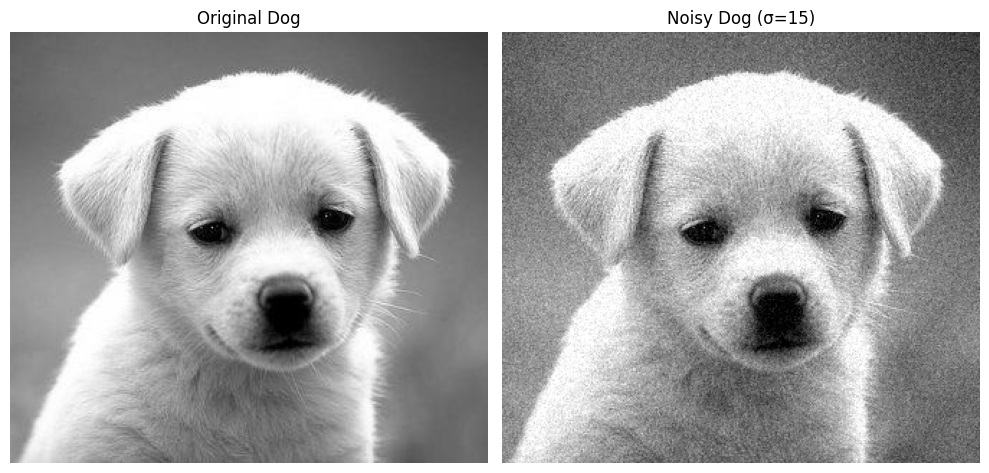

In [8]:
uploaded = files.upload()
dog_filename = list(uploaded.keys())[0]
dog = Image.open(io.BytesIO(uploaded[dog_filename])).convert('L')  # converting it to grayscale
dog = np.array(dog, dtype=np.float64)  # converting it to numpy array
print(dog.shape)

np.random.seed(42)
noise      = np.random.normal(loc=0, scale=15, size=dog.shape)
dog_noisy  = dog + noise

dog_noisy_clipped = np.clip(dog_noisy, 0, 255)

# Display the noisy image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(dog.astype(np.uint8), cmap='gray')
plt.title('Original Dog')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dog_noisy_clipped.astype(np.uint8), cmap='gray')
plt.title('Noisy Dog (σ=15)')
plt.axis('off')

plt.tight_layout()

print(f"noise mean={noise.mean():.4f}, std={noise.std():.4f}")

## Question 2:

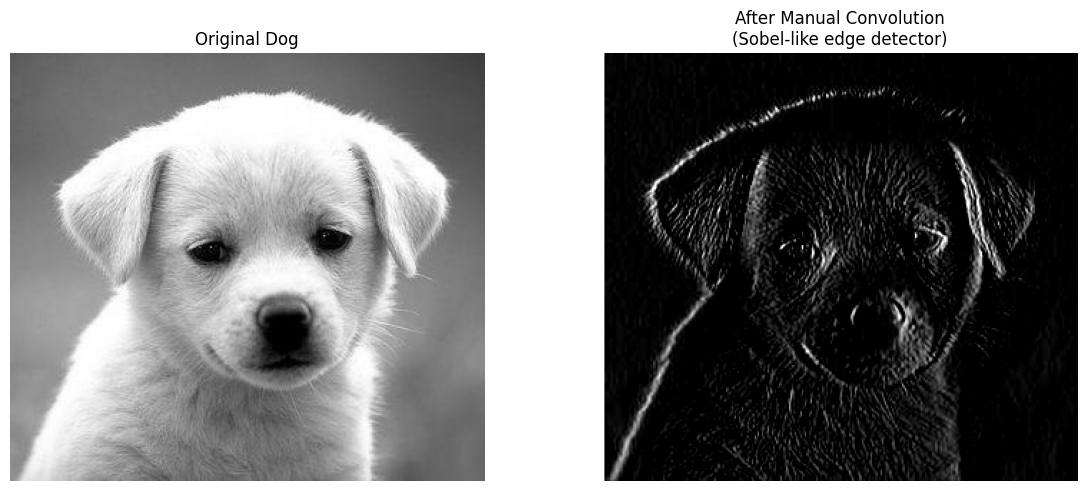

In [9]:

def manual_convolve(image, kernel):
    kH, kW = kernel.shape
    pH, pW = kH // 2, kW // 2
    padded = np.pad(image, ((pH, pH), (pW, pW)), mode='constant', constant_values=0)
    k_flipped = np.flip(kernel)
    H, W = image.shape
    output = np.zeros_like(image, dtype=np.float64)
    for i in range(H):
        for j in range(W):
            region       = padded[i:i + kH, j:j + kW]
            output[i, j] = np.sum(region * k_flipped)
    return output

kernel_q2 = np.array([[1, 0, -1],
                       [2, 0, -2],
                       [1, 0, -1]], dtype=np.float64)
conv_result = manual_convolve(dog, kernel_q2)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(dog.astype(np.uint8), cmap='gray')
axes[0].set_title('Original Dog', fontsize=12)
axes[0].axis('off')
axes[1].imshow(np.clip(conv_result, 0, 255).astype(np.uint8), cmap='gray')
axes[1].set_title('After Manual Convolution\n(Sobel-like edge detector)', fontsize=12)
axes[1].axis('off')
plt.tight_layout()
plt.show()


## Question 3:

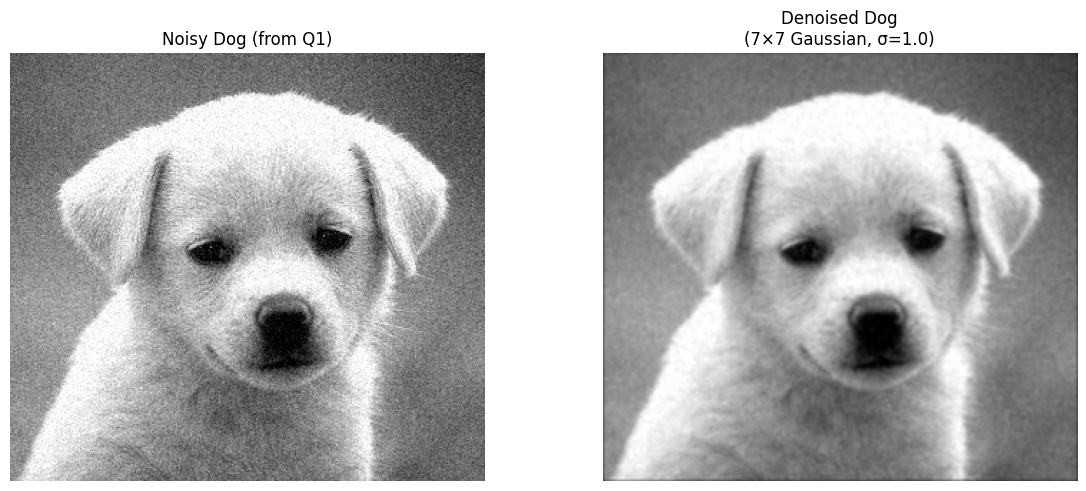

In [10]:
def gaussian_kernel(size, sigma):
    half = size // 2
    ax = np.arange(-half, half + 1, dtype=np.float64)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / kernel.sum()      # normalise so weights sum to 1

gauss_kernel = gaussian_kernel(size=7, sigma=1.0)
dog_denoised = manual_convolve(dog_noisy, gauss_kernel)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(np.clip(dog_noisy, 0, 255).astype(np.uint8), cmap='gray')
axes[0].set_title('Noisy Dog (from Q1)', fontsize=12)
axes[0].axis('off')
axes[1].imshow(np.clip(dog_denoised, 0, 255).astype(np.uint8), cmap='gray')
axes[1].set_title('Denoised Dog\n(7×7 Gaussian, σ=1.0)', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

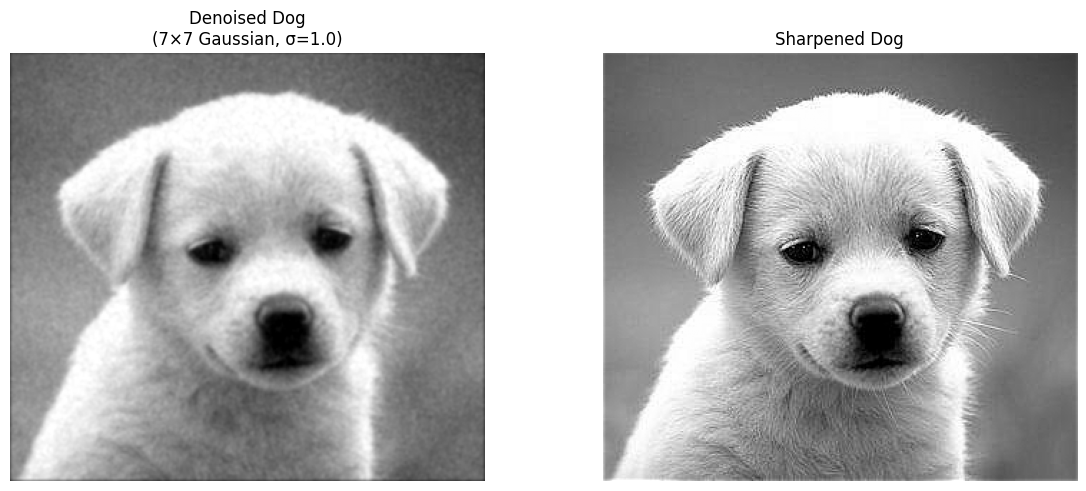

In [11]:
sharpening_kernel = np.array([
    [ 1,  4,  6,  4,  1],
    [ 4, 16, 24, 16,  4],
    [ 6, 24, -476, 24, 6],
    [ 4, 16, 24, 16,  4],
    [ 1,  4,  6,  4,  1]
], dtype=np.float64) * -1.0 / 256.0

dog_sharpened = manual_convolve(dog, sharpening_kernel)

# display denoised and sharpened
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(np.clip(dog_denoised, 0, 255).astype(np.uint8), cmap='gray')
axes[0].set_title('Denoised Dog\n(7×7 Gaussian, σ=1.0)', fontsize=12)
axes[0].axis('off')
axes[1].imshow(np.clip(dog_sharpened, 0, 255).astype(np.uint8), cmap='gray')
axes[1].set_title('Sharpened Dog', fontsize=12)
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Question 4:

In [21]:
uploaded = files.upload()
shelf_filename = list(uploaded.keys())[0]
shelf = Image.open(io.BytesIO(uploaded[shelf_filename])).convert('L')
shelf = np.array(shelf, dtype=np.float64)
uploaded = files.upload()
template_filename = list(uploaded.keys())[0]
template = Image.open(io.BytesIO(uploaded[template_filename])).convert('L')
template = np.array(template, dtype=np.float64)

# Resize template if larger than shelf
if template.shape[0] > shelf.shape[0] or template.shape[1] > shelf.shape[1]:
    scale = min(shelf.shape[0] / template.shape[0], shelf.shape[1] / template.shape[1]) * 0.5
    new_h = int(template.shape[0] * scale)
    new_w = int(template.shape[1] * scale)
    template = np.array(Image.fromarray(template.astype(np.uint8)).resize((new_w, new_h)), dtype=np.float64)

print(f"Shelf size: {shelf.shape}, Template size: {template.shape}")


Saving shelf.jpg to shelf (1).jpg


Saving template.jpg to template (1).jpg
Shelf size: (400, 1000), Template size: (56, 39)


In [22]:
def template_match_convolution(image, template):
    img_mean = image.mean()
    tmpl_mean= template.mean()
    img_c = image - img_mean      # mean-subtract image
    tmpl_c = template - tmpl_mean     # mean-subtract template
    # flip template (180°) before passing to convolution function
    tmpl_flipped = np.flip(tmpl_c)

    kH, kW = tmpl_flipped.shape
    pH, pW = kH // 2, kW // 2
    padded = np.pad(img_c, ((pH, pH), (pW, pW)), mode='constant', constant_values=0)
    H, W   = image.shape
    output = np.zeros((H, W), dtype=np.float64)
    for i in range(H):
        for j in range(W):
            region      = padded[i:i + kH, j:j + kW]
            output[i, j] = np.sum(region * tmpl_flipped)
    return output


In [23]:
def template_match_correlation(image, template):
    img_mean = image.mean()
    tmpl_mean = template.mean()
    img_c = image - img_mean
    tmpl_c= template - tmpl_mean

    kH, kW = tmpl_c.shape
    pH, pW = kH // 2, kW // 2
    padded = np.pad(img_c, ((pH, pH), (pW, pW)), mode='constant', constant_values=0)
    H, W   = image.shape
    output = np.zeros((H, W), dtype=np.float64)
    for i in range(H):
        for j in range(W):
            region = padded[i:i + kH, j:j + kW]
            output[i, j] = np.sum(region * tmpl_c)  #no flip as it is correlation
    return output

In [24]:
print("Running template matching (this may take a minute)...")
conv_map = template_match_convolution(shelf, template)
corr_map = template_match_correlation(shelf, template)

conv_loc = np.unravel_index(np.argmax(conv_map), conv_map.shape)
corr_loc = np.unravel_index(np.argmax(corr_map), corr_map.shape)
print(f"Convolution best match at: {conv_loc}")
print(f"Correlation best match at: {corr_loc}")

Running template matching (this may take a minute)...
Convolution best match at: (np.int64(342), np.int64(172))
Correlation best match at: (np.int64(36), np.int64(60))


In [25]:
def draw_box(image, location, template_shape, color=255):
    result = np.stack([image] * 3, axis=-1).astype(np.uint8)
    r, c   = location
    h, w   = template_shape
    r1, c1 = max(0, r - h // 2), max(0, c - w // 2)
    r2, c2 = min(image.shape[0]-1, r + h // 2), min(image.shape[1]-1, c + w // 2)
    result[r1:r2, c1, :] = [255, 0, 0]
    result[r1:r2, c2, :] = [255, 0, 0]
    result[r1, c1:c2, :] = [255, 0, 0]
    result[r2, c1:c2, :] = [255, 0, 0]
    return result

shelf_conv_vis = draw_box(shelf, conv_loc, template.shape)
shelf_corr_vis = draw_box(shelf, corr_loc, template.shape)

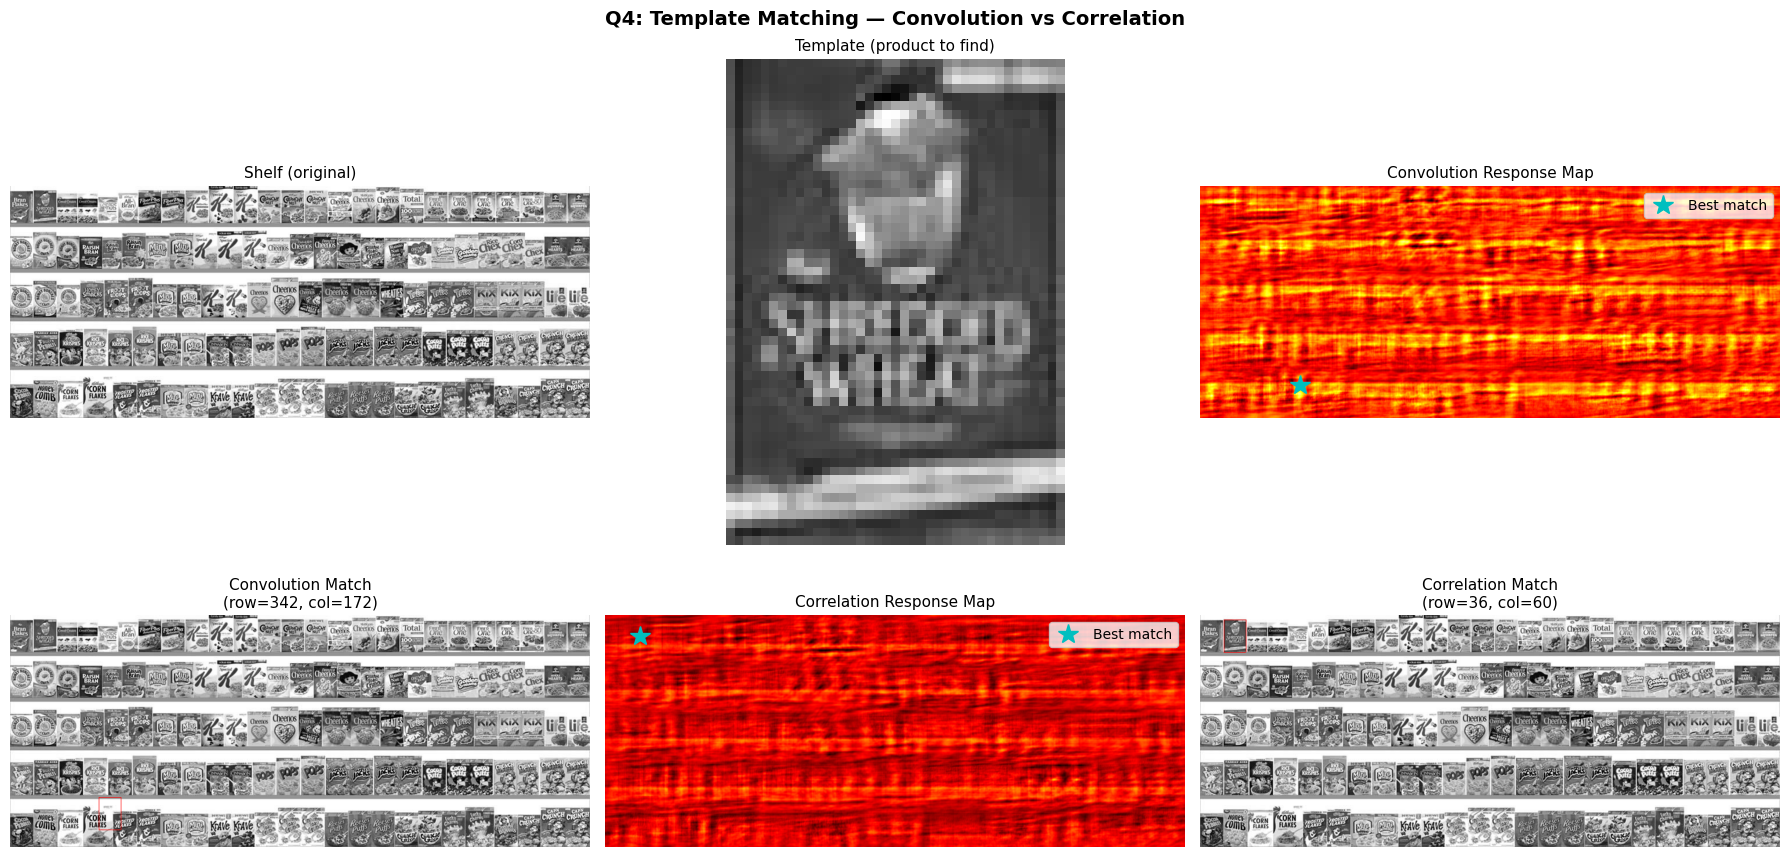

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].imshow(shelf.astype(np.uint8), cmap='gray')
axes[0, 0].set_title('Shelf (original)', fontsize=11)
axes[0, 0].axis('off')

axes[0, 1].imshow(template.astype(np.uint8), cmap='gray')
axes[0, 1].set_title('Template (product to find)', fontsize=11)
axes[0, 1].axis('off')

axes[0, 2].imshow(conv_map, cmap='hot')
axes[0, 2].plot(conv_loc[1], conv_loc[0], 'c*', markersize=15, label='Best match')
axes[0, 2].set_title('Convolution Response Map', fontsize=11)
axes[0, 2].legend()
axes[0, 2].axis('off')

axes[1, 0].imshow(shelf_conv_vis)
axes[1, 0].set_title(f'Convolution Match\n(row={conv_loc[0]}, col={conv_loc[1]})', fontsize=11)
axes[1, 0].axis('off')

axes[1, 1].imshow(corr_map, cmap='hot')
axes[1, 1].plot(corr_loc[1], corr_loc[0], 'c*', markersize=15, label='Best match')
axes[1, 1].set_title('Correlation Response Map', fontsize=11)
axes[1, 1].legend()
axes[1, 1].axis('off')

axes[1, 2].imshow(shelf_corr_vis)
axes[1, 2].set_title(f'Correlation Match\n(row={corr_loc[0]}, col={corr_loc[1]})', fontsize=11)
axes[1, 2].axis('off')

plt.suptitle('Q4: Template Matching — Convolution vs Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig('q4_template_matching.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

## e) Which method more accurately locates the product?
     Correlation is more accurate for template matching.Because the template is not flipped, it slides across
     the image in its natural orientation, so the dot-product directly measures structural similarity at each position.
     Convolution flips the template, which can shift the peak location unless the template is symmetric.

## f) Which method is more efficient?
     Both have the same computational cost O(H×W×kH×kW).In practice, correlation is simpler to implement (no flip step) and is the standard choice in cv.matchTemplate.

## g) Why is correlation better for template matching?
     Template matching is a similarity search, we want to find where the image looks like our template. Correlation does this directly: high values = good match.
     Convolution flips the template, so we're looking for the template upside-down. That's useful for filtering (edge detection) but wrong for matching.
     Each tool has its job: Correlation = matching, Convolution = filtering.